# North DFW Housing Affordability Crisis
## Notebook 04: Predictive Model

**Author:** Alejandro Molina  
**GitHub:** https://github.com/chooseyourtacoday  
**Date:** 2026

---

### Notebook Goal
Build a Random Forest model to forecast home values and affordability index 24 months into the future for each North DFW zip code.

### Approach
- **Model type:** Random Forest Regressor
- **Target variable:** `home_value` (12-month forward)
- **Train period:** 2015-2023
- **Test period:** 2024-present
- **Forecast horizon:** 24 months beyond most recent data point

### Why Random Forest?
- Handles non-linear relationships between features
- Robust to outliers (important given the COVID price spike)
- Provides feature importance scores that answer *what is driving prices*
- No assumption of normally distributed data required

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

FEATURES_DIR = os.path.join('data', 'features')
OUTPUT_DIR   = os.path.join('data', 'predictions')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Libraries loaded.')
print(f'Features dir : {FEATURES_DIR}')
print(f'Output dir   : {OUTPUT_DIR}')

Libraries loaded.
Features dir : data\features
Output dir   : data\predictions


## Step 2: Load Feature Dataset

In [2]:
df = pd.read_csv(
    os.path.join(FEATURES_DIR, 'dfw_housing_features.csv'),
    parse_dates=['date']
)

print(f'Features loaded : {df.shape}')
print(f'Date range      : {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Cities          : {sorted(df["city"].unique().tolist())}')

Features loaded : (1755, 28)
Date range      : 2015-01-31 to 2026-03-31
Cities          : ['Allen', 'Celina', 'Frisco', 'McKinney', 'Plano', 'Prosper']


## Step 3: Prepare Model Features
Select the features that will drive the prediction.
We encode the city as a numeric variable so the model can learn city-specific patterns.

In [3]:
# Encode city as numeric
le = LabelEncoder()
df['city_encoded'] = le.fit_transform(df['city'])

# Define feature columns
FEATURE_COLS = [
    'city_encoded',
    'year',
    'month',
    'mortgage_rate',
    'total_units',
    'collin_avg_annual_pay',
    'population',
    'median_income',
    'price_to_income_ratio',
    'mortgage_burden_pct',
    'home_value_mom',
    'home_value_yoy',
    'wage_growth_yoy',
    'affordability_gap',
    'supply_pressure',
    'affordability_index'
]

TARGET_COL = 'home_value'

# Drop rows with nulls in features or target
model_df = df[FEATURE_COLS + [TARGET_COL, 'date', 'city', 'zip_code']].dropna()

print(f'Model dataset shape : {model_df.shape}')
print(f'Features            : {len(FEATURE_COLS)}')
print(f'Date range          : {model_df["date"].min().date()} to {model_df["date"].max().date()}')

Model dataset shape : (1599, 20)
Features            : 16
Date range          : 2016-01-31 to 2026-03-31


## Step 4: Train / Test Split
We split chronologically — train on 2015-2023, test on 2024-present.
This simulates real-world forecasting where we predict future values from past data.

In [4]:
SPLIT_DATE = '2024-01-01'

train = model_df[model_df['date'] < SPLIT_DATE]
test  = model_df[model_df['date'] >= SPLIT_DATE]

X_train = train[FEATURE_COLS]
y_train = train[TARGET_COL]

X_test  = test[FEATURE_COLS]
y_test  = test[TARGET_COL]

print(f'Train size : {X_train.shape[0]} rows ({train["date"].min().date()} to {train["date"].max().date()})')
print(f'Test size  : {X_test.shape[0]} rows ({test["date"].min().date()} to {test["date"].max().date()})')

Train size : 1248 rows (2016-01-31 to 2023-12-31)
Test size  : 351 rows (2024-01-31 to 2026-03-31)


## Step 5: Train Random Forest Model

In [5]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print('Model trained successfully.')

Model trained successfully.


## Step 6: Evaluate Model on Test Set

In [6]:
y_pred = rf_model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print('=== MODEL EVALUATION ===')
print(f'R² Score  : {r2:.4f}  (1.0 = perfect, 0.0 = no better than mean)')
print(f'MAE       : ${mae:,.0f}  (average prediction error in dollars)')
print(f'RMSE      : ${rmse:,.0f}  (penalizes large errors more heavily)')
print(f'\nMean actual home value  : ${y_test.mean():,.0f}')
print(f'Mean predicted value    : ${y_pred.mean():,.0f}')
print(f'MAE as % of mean price  : {(mae / y_test.mean() * 100):.1f}%')

=== MODEL EVALUATION ===
R² Score  : 0.9330  (1.0 = perfect, 0.0 = no better than mean)
MAE       : $18,488  (average prediction error in dollars)
RMSE      : $28,415  (penalizes large errors more heavily)

Mean actual home value  : $597,252
Mean predicted value    : $581,363
MAE as % of mean price  : 3.1%


## Step 7: Feature Importance
Which variables are most responsible for driving home prices?
This directly answers: *what is causing the crisis?*

=== FEATURE IMPORTANCE ===
              feature  importance
  affordability_index    0.578114
  mortgage_burden_pct    0.285243
price_to_income_ratio    0.032030
        median_income    0.024921
collin_avg_annual_pay    0.019818
                 year    0.019214
         city_encoded    0.010562
       home_value_mom    0.006212
           population    0.005028
      supply_pressure    0.004634
        mortgage_rate    0.004510
    affordability_gap    0.003297
      wage_growth_yoy    0.003145
       home_value_yoy    0.002680
                month    0.000401
          total_units    0.000194


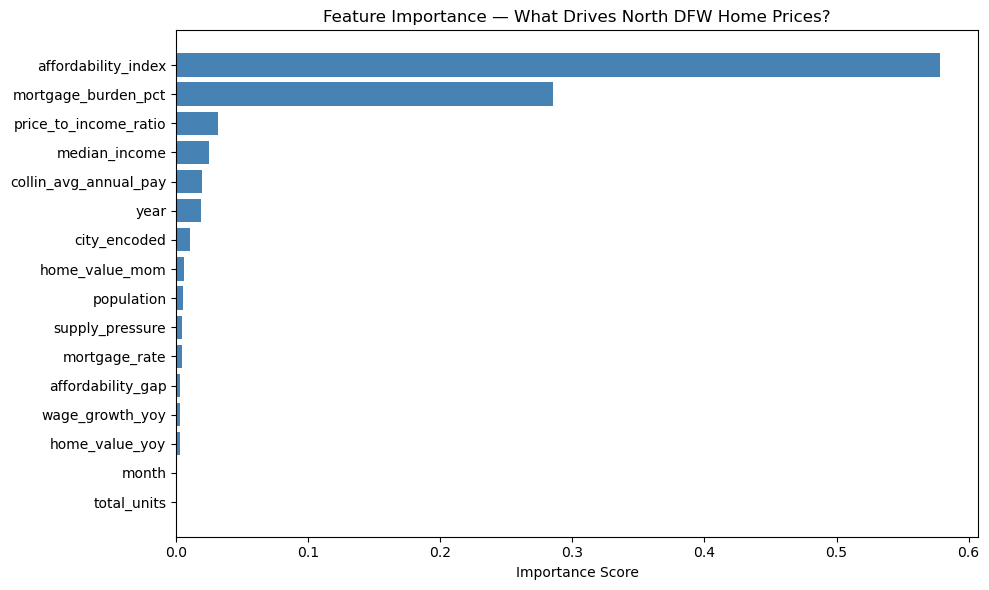

Chart saved.


In [7]:
importance_df = pd.DataFrame({
    'feature'   : FEATURE_COLS,
    'importance' : rf_model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print('=== FEATURE IMPORTANCE ===')
print(importance_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance_df['feature'][::-1], importance_df['importance'][::-1], color='steelblue')
ax.set_xlabel('Importance Score')
ax.set_title('Feature Importance — What Drives North DFW Home Prices?')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

## Step 8: Generate 24-Month Forecast
Project home values forward 24 months from the most recent data point using the trained model.

In [8]:
FORECAST_MONTHS = 24

# Get the most recent row per zip code as starting point
last_known = model_df.sort_values('date').groupby('zip_code').last().reset_index()

forecast_rows = []

for _, row in last_known.iterrows():
    current = row.copy()

    for i in range(1, FORECAST_MONTHS + 1):
        # Advance date by one month
        next_date = current['date'] + pd.DateOffset(months=1)

        # Build feature row
        feat_row = {
            'zip_code'              : current['zip_code'],
            'city'                  : current['city'],
            'date'                  : next_date,
            'city_encoded'          : current['city_encoded'],
            'year'                  : next_date.year,
            'month'                 : next_date.month,
            'mortgage_rate'         : current['mortgage_rate'],
            'total_units'           : current['total_units'],
            'collin_avg_annual_pay' : current['collin_avg_annual_pay'] * 1.03,  # assume 3% annual wage growth
            'population'            : current['population'] * 1.005,            # assume 0.5% monthly growth
            'median_income'         : current['median_income'],
            'price_to_income_ratio' : current['price_to_income_ratio'],
            'mortgage_burden_pct'   : current['mortgage_burden_pct'],
            'home_value_mom'        : current['home_value_mom'],
            'home_value_yoy'        : current['home_value_yoy'],
            'wage_growth_yoy'       : current['wage_growth_yoy'],
            'affordability_gap'     : current['affordability_gap'],
            'supply_pressure'       : current['supply_pressure'],
            'affordability_index'   : current['affordability_index']
        }

        # Predict home value
        X_forecast = pd.DataFrame([feat_row])[FEATURE_COLS]
        predicted_value = rf_model.predict(X_forecast)[0]

        feat_row['home_value']  = predicted_value
        feat_row['is_forecast'] = True
        forecast_rows.append(feat_row)

        # Update current for next iteration
        current = pd.Series(feat_row)
        current['date'] = next_date

forecast_df = pd.DataFrame(forecast_rows)
print(f'Forecast generated : {forecast_df.shape[0]} rows')
print(f'Forecast period    : {forecast_df["date"].min().date()} to {forecast_df["date"].max().date()}')

Forecast generated : 312 rows
Forecast period    : 2026-04-30 to 2028-03-28


## Step 9: Forecast Summary by City

In [9]:
# Get current and forecast end values per city
current_values  = last_known.groupby('city')['home_value'].mean()
forecast_end    = forecast_df[forecast_df['date'] == forecast_df['date'].max()].groupby('city')['home_value'].mean()

forecast_summary = pd.DataFrame({
    'current_value'  : current_values,
    'forecast_value' : forecast_end
}).round(0)

forecast_summary['change_$'] = (forecast_summary['forecast_value'] - forecast_summary['current_value']).round(0)
forecast_summary['change_%'] = ((forecast_summary['change_$'] / forecast_summary['current_value']) * 100).round(2)

print('=== 24-MONTH FORECAST SUMMARY ===')
print(forecast_summary.sort_values('forecast_value', ascending=False).to_string())

=== 24-MONTH FORECAST SUMMARY ===
          current_value  forecast_value  change_$  change_%
city                                                       
Prosper        755846.0        615636.0 -140210.0    -18.55
Frisco         663940.0        589327.0  -74613.0    -11.24
Allen          555711.0        557346.0    1635.0      0.29
Celina         537553.0        516074.0  -21479.0     -4.00
Plano          535577.0        511118.0  -24459.0     -4.57
McKinney       460132.0        448602.0  -11530.0     -2.51


## Step 10: Visualize Forecast by City

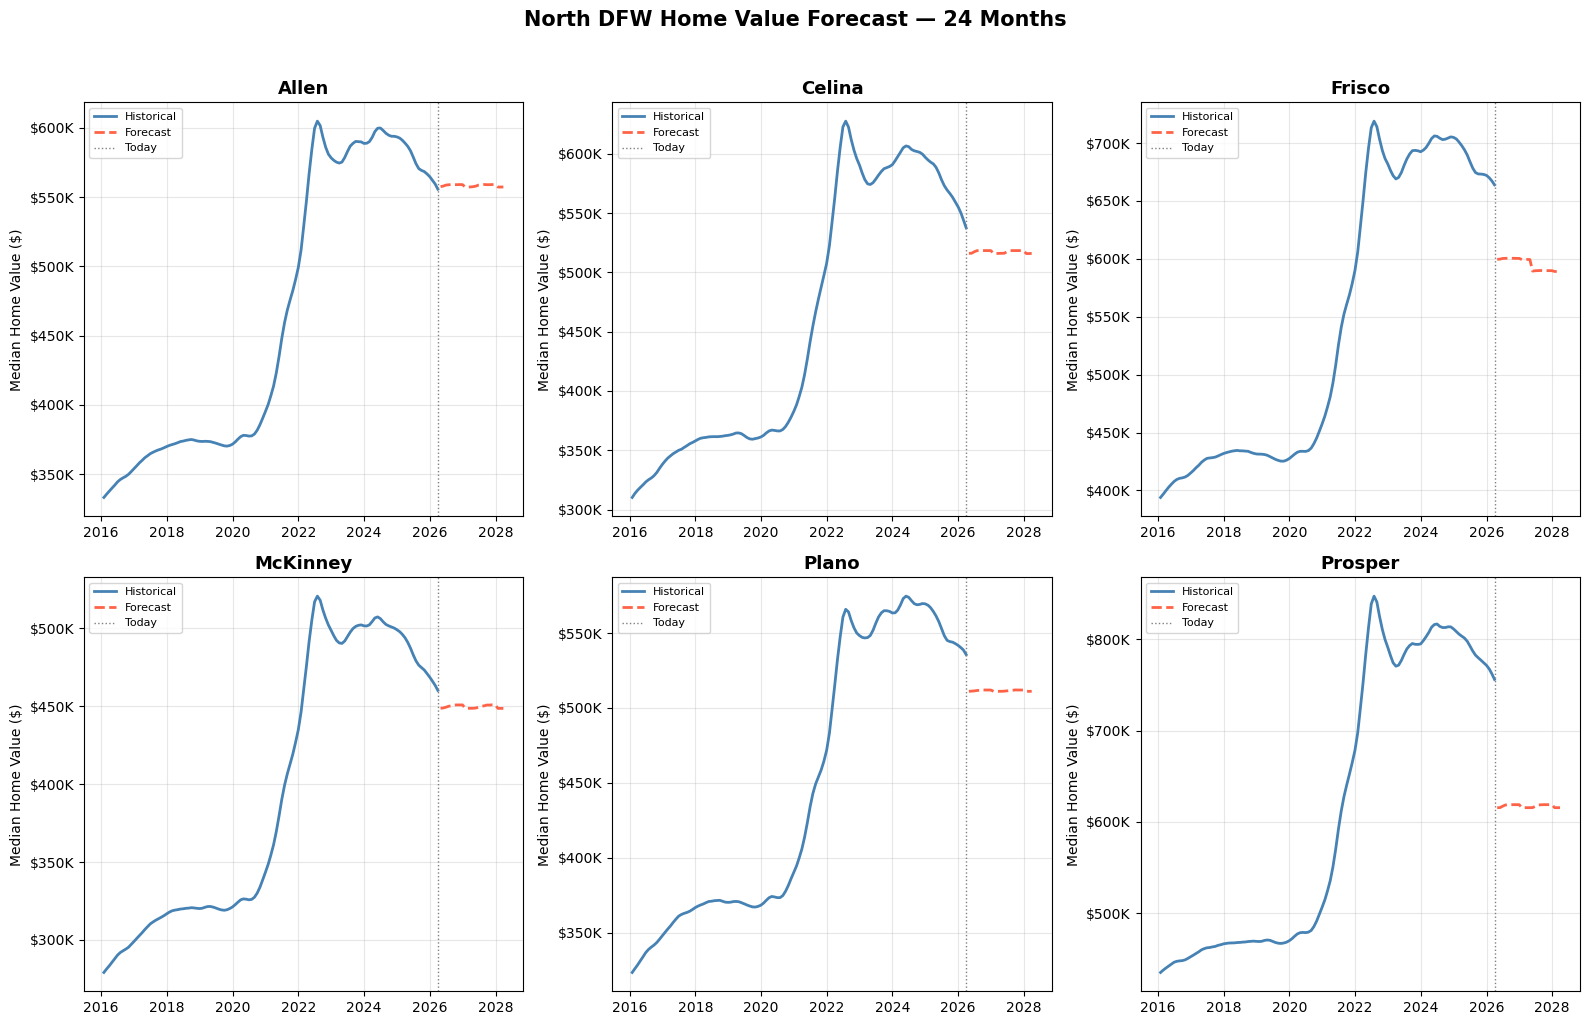

Chart saved.


In [10]:
cities = sorted(df['city'].unique())
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, city in enumerate(cities):
    ax = axes[idx]

    # Historical data
    hist = model_df[model_df['city'] == city].groupby('date')['home_value'].mean().reset_index()

    # Forecast data
    fore = forecast_df[forecast_df['city'] == city].groupby('date')['home_value'].mean().reset_index()

    ax.plot(hist['date'], hist['home_value'], color='steelblue', linewidth=2, label='Historical')
    ax.plot(fore['date'], fore['home_value'], color='tomato', linewidth=2, linestyle='--', label='Forecast')
    ax.axvline(x=model_df['date'].max(), color='gray', linestyle=':', linewidth=1, label='Today')

    ax.set_title(city, fontsize=13, fontweight='bold')
    ax.set_ylabel('Median Home Value ($)')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('North DFW Home Value Forecast — 24 Months', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'forecast_by_city.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

## Step 11: Save Predictions

In [11]:
# Tag historical data
model_df['is_forecast'] = False

# Combine historical and forecast
combined = pd.concat([
    model_df[['zip_code', 'city', 'date', 'home_value', 'is_forecast']],
    forecast_df[['zip_code', 'city', 'date', 'home_value', 'is_forecast']]
], ignore_index=True)

combined = combined.sort_values(['zip_code', 'date']).reset_index(drop=True)

# Save outputs
combined.to_csv(os.path.join(OUTPUT_DIR, 'home_value_predictions.csv'), index=False)
forecast_summary.to_csv(os.path.join(OUTPUT_DIR, 'forecast_summary.csv'))
importance_df.to_csv(os.path.join(OUTPUT_DIR, 'feature_importance.csv'), index=False)

print('=' * 60)
print('NOTEBOOK 04 COMPLETE — PREDICTIVE MODEL SUMMARY')
print('=' * 60)
print(f'\nModel        : Random Forest Regressor')
print(f'R² Score     : {r2:.4f}')
print(f'MAE          : ${mae:,.0f}')
print(f'RMSE         : ${rmse:,.0f}')
print(f'\nForecast horizon : 24 months')
print(f'Forecast rows    : {forecast_df.shape[0]}')
print(f'\nFiles saved to   : {OUTPUT_DIR}')
print('  home_value_predictions.csv')
print('  forecast_summary.csv')
print('  feature_importance.png')
print('  forecast_by_city.png')
print('\nNext: Notebook 05 — Model Evaluation & Tableau Export')

NOTEBOOK 04 COMPLETE — PREDICTIVE MODEL SUMMARY

Model        : Random Forest Regressor
R² Score     : 0.9330
MAE          : $18,488
RMSE         : $28,415

Forecast horizon : 24 months
Forecast rows    : 312

Files saved to   : data\predictions
  home_value_predictions.csv
  forecast_summary.csv
  feature_importance.png
  forecast_by_city.png

Next: Notebook 05 — Model Evaluation & Tableau Export
